In [1]:
import torch
from numpy.f2py.auxfuncs import throw_error
from torch import nn
from torch.nn import functional as F
from torch.nn import Linear, ReLU, Sequential, Conv2d
from torch.optim import Adam, SGD
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split

In [2]:
# Defining device for training, x, y and f(x, y)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X, y = torch.arange(0, 10, 0.1), torch.arange(0, 10, 0.1)
XX, yy = torch.meshgrid(X, y, indexing='ij')

X_cords = XX.flatten()
y_cords = yy.flatten()

z = 0.5 * X_cords ** 2 - 2 * y_cords ** 2 + X_cords - 1

X_y = torch.cat((X_cords.unsqueeze(1), y_cords.unsqueeze(1)), dim=1)
X_y_train, X_y_test, z_train, z_test = [i.to(device) for i in train_test_split(X_y, z, test_size=0.2, random_state=42)]
print(f'Device: {device}')
len(X_y_train), len(X_y_test), X_y[:5]

Device: cuda


(8000,
 2000,
 tensor([[0.0000, 0.0000],
         [0.0000, 0.1000],
         [0.0000, 0.2000],
         [0.0000, 0.3000],
         [0.0000, 0.4000]]))

In [3]:
X_y_train.shape, z_train.shape, z_test.shape

(torch.Size([8000, 2]), torch.Size([8000]), torch.Size([2000]))

In [4]:
# Feed forward backpropagation model
class FeedForward(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.modules_seq = Sequential(Linear(2, hidden_dim), ReLU(), Linear(hidden_dim, 1))

    def forward(self, input_X_y):
        return self.modules_seq(input_X_y)

# Cascade forward backpropagation model
class CascadeForward(nn.Module):
    def __init__(self, num_of_dim, hidden_dim):
        super().__init__()
        self.num_of_dim = num_of_dim
        self.hidden_layer_1 = nn.Linear(2, hidden_dim)
        if num_of_dim == 1:
            self.output = nn.Linear(2 + hidden_dim, 1)
        elif num_of_dim == 2:
            self.hidden_layer_2 = nn.Linear(2 + hidden_dim, hidden_dim)
            self.output = nn.Linear(2 + hidden_dim + hidden_dim, 1)
        else:
            throw_error('num_of_dim must be 1 or 2')

    def forward(self, input_X_y):
        h1_layer_out = F.relu(self.hidden_layer_1(input_X_y))
        if self.num_of_dim == 1:
            output_in = torch.cat((input_X_y, h1_layer_out), dim=1)
            return self.output(output_in)

        elif self.num_of_dim == 2:
            h2_layer_in = torch.cat((input_X_y, h1_layer_out), dim=1)
            h2_layer_out = F.relu(self.hidden_layer_2(h2_layer_in))

            output_in = torch.cat((input_X_y, h1_layer_out, h2_layer_out), dim=1)
            return self.output(output_in)

        else:
            throw_error('num_of_dim must be 1 or 2')
            return None

In [11]:
def training_loop(model, input_train, input_test, output_train, output_test, num_epochs=500):
    optimizer = Adam(model.parameters(), lr=0.03)
    criterion = nn.MSELoss().to(device)

    train_loss_lt = []
    test_loss_lt = []
    epoch_count = []

    for epoch in range(num_epochs):
        model.train()
        train_pred = model(input_train)
        loss = criterion(train_pred, output_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.inference_mode():
            test_pred = model(input_test)
            test_loss = criterion(test_pred, output_test)

            if epoch % 100 == 0:
                epoch_count.append(epoch)
                train_loss_lt.append(loss.item())
                test_loss_lt.append(test_loss.item())
                print(f'Epoch: {epoch}, Train Loss: {loss.item()}, Test Loss: {test_loss.item()}')

            if test_loss.item() < 3:
                break



    plt.clf()
    plt.plot(epoch_count, train_loss_lt, label="Train loss")
    plt.plot(epoch_count, test_loss_lt, label="Test loss")
    plt.title("Training and test loss curves")
    plt.yscale('log')
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()

Epoch: 0, Train Loss: 5907.77099609375, Test Loss: 5577.5361328125
Epoch: 100, Train Loss: 255.83839416503906, Test Loss: 256.05279541015625
Epoch: 200, Train Loss: 154.89576721191406, Test Loss: 154.37376403808594
Epoch: 300, Train Loss: 95.0845947265625, Test Loss: 94.83641052246094
Epoch: 400, Train Loss: 60.646968841552734, Test Loss: 60.6525764465332
Epoch: 500, Train Loss: 37.6331901550293, Test Loss: 37.270565032958984
Epoch: 600, Train Loss: 22.778953552246094, Test Loss: 22.087446212768555
Epoch: 700, Train Loss: 16.246950149536133, Test Loss: 15.956518173217773
Epoch: 800, Train Loss: 12.585102081298828, Test Loss: 12.53395938873291
Epoch: 900, Train Loss: 10.360135078430176, Test Loss: 10.430498123168945
Epoch: 1000, Train Loss: 8.90881061553955, Test Loss: 9.020611763000488
Epoch: 1100, Train Loss: 7.899085998535156, Test Loss: 8.047094345092773
Epoch: 1200, Train Loss: 7.161541938781738, Test Loss: 7.34578275680542
Epoch: 1300, Train Loss: 6.613162517547607, Test Loss: 6.7

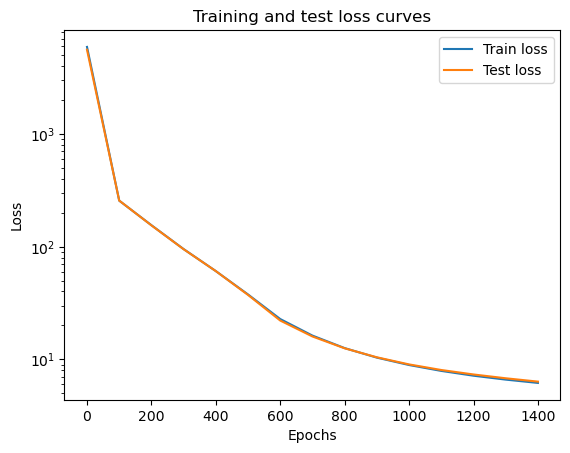

In [12]:
# Model with 10 neurons in a hidden layer
model_feed_forward_0 = FeedForward(hidden_dim=10).to(device)
training_loop(model_feed_forward_0, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 1500)

Epoch: 0, Train Loss: 5683.1123046875, Test Loss: 5314.9951171875
Epoch: 100, Train Loss: 174.28085327148438, Test Loss: 173.67523193359375
Epoch: 200, Train Loss: 86.9955062866211, Test Loss: 86.05541229248047
Epoch: 300, Train Loss: 26.680879592895508, Test Loss: 25.866779327392578
Epoch: 400, Train Loss: 11.600517272949219, Test Loss: 11.621732711791992
Epoch: 500, Train Loss: 6.9379658699035645, Test Loss: 7.009973526000977
Epoch: 600, Train Loss: 5.125033378601074, Test Loss: 5.26380729675293
Epoch: 700, Train Loss: 4.054300785064697, Test Loss: 4.211170673370361
Epoch: 800, Train Loss: 3.293027400970459, Test Loss: 3.464221954345703


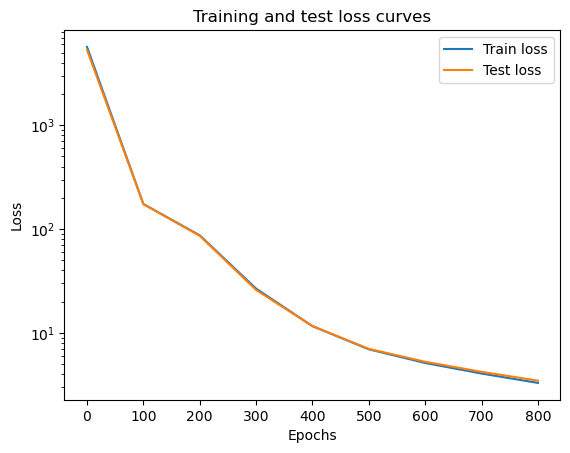

In [13]:
# Creating a new model, but with more neurons in a hidden layer
model_feed_forward_1 = FeedForward(hidden_dim=20).to(device)
training_loop(model_feed_forward_1, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 1500)

Epoch: 0, Train Loss: 5743.94140625, Test Loss: 5396.3564453125
Epoch: 100, Train Loss: 204.6605682373047, Test Loss: 204.67364501953125
Epoch: 200, Train Loss: 71.4688949584961, Test Loss: 69.578857421875
Epoch: 300, Train Loss: 24.765153884887695, Test Loss: 24.21298599243164
Epoch: 400, Train Loss: 13.424162864685059, Test Loss: 13.546043395996094
Epoch: 500, Train Loss: 10.15312385559082, Test Loss: 10.565732955932617
Epoch: 600, Train Loss: 8.474358558654785, Test Loss: 8.860488891601562
Epoch: 700, Train Loss: 7.568965435028076, Test Loss: 7.953830242156982
Epoch: 800, Train Loss: 6.855800151824951, Test Loss: 7.288449764251709
Epoch: 900, Train Loss: 6.306385517120361, Test Loss: 6.739221096038818
Epoch: 1000, Train Loss: 5.663405895233154, Test Loss: 5.960635185241699
Epoch: 1100, Train Loss: 5.227409362792969, Test Loss: 5.423307418823242
Epoch: 1200, Train Loss: 4.8023786544799805, Test Loss: 4.957738399505615
Epoch: 1300, Train Loss: 4.362098693847656, Test Loss: 4.479127883

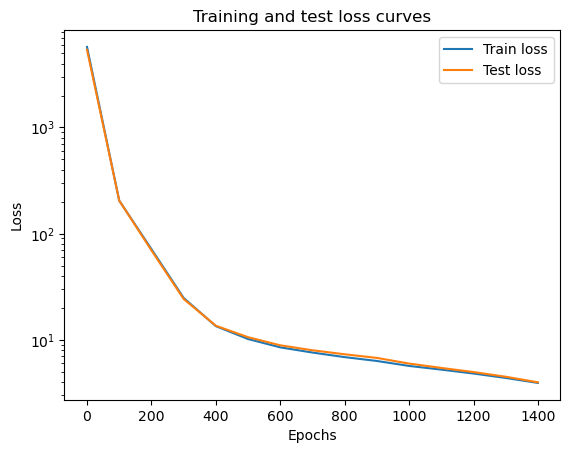

In [14]:
model_cascade_forward_0 = CascadeForward(1, 20).to(device)
training_loop(model_cascade_forward_0, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 1500)

Epoch: 0, Train Loss: 5842.29638671875, Test Loss: 5418.2958984375
Epoch: 100, Train Loss: 131.53482055664062, Test Loss: 127.33894348144531
Epoch: 200, Train Loss: 58.31763458251953, Test Loss: 56.168575286865234
Epoch: 300, Train Loss: 14.312407493591309, Test Loss: 13.498053550720215
Epoch: 400, Train Loss: 8.835017204284668, Test Loss: 8.381888389587402


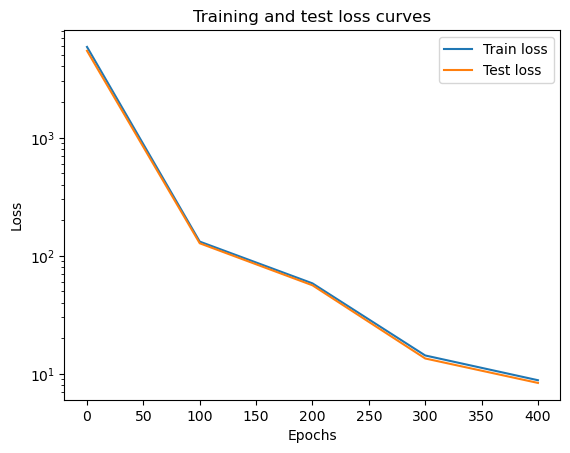

In [15]:
model_cascade_forward_1 = CascadeForward(2, 10).to(device)
training_loop(model_cascade_forward_1, X_y_train, X_y_test, z_train.unsqueeze(1), z_test.unsqueeze(1), 1500)